# Structure-profile tutorial

This script uses RNA secondary-structure profiles (derived from `RNAplfold`),
aggregates per-transcript profiles into a mean profile for each structure type, optionally z-scores
each structure type (row-wise), and draws a heatmap and a profile plot.

RNAplfold-derived structure profiles tutorial:

Smoothed profile curves using `Gaussian Process Regression (GPR)`

Input format (one block per transcript/region):

    >HEADER
    <Paired scores>         (101 tab-separated floats)
    <Hairpin loop scores>   (101 floats)
    <Multi loop scores>     (101 floats)
    <Inner loop scores>     (101 floats)
    <External loop scores>  (101 floats)

References (RNAplfold, ViennaRNA):
- RNAplfold page: [https://www.tbi.univie.ac.at/RNA/RNAplfold.1.html](https://www.tbi.univie.ac.at/RNA/RNAplfold.1.html)
- ViennaRNA Package: [https://www.tbi.univie.ac.at/RNA/](https://www.tbi.univie.ac.at/RNA/)

Outputs:
- *_profile_gpr.pdf    : GPR-smoothed mean curves with uncertainty bands

## Import libraries

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

## Constants & Configuration

Define the structure types to be analyzed and the coordinate system for the profile (relative to the binding site center).

In [2]:
rcParams["font.family"] = "Calibri"

# -----------------------------
# Constants
# -----------------------------
STRUCTURE_TYPES: Tuple[str, ...] = (
    "Paired",
    "Hairpin loop",
    "Multi loop",
    "Inner loop",
    "External loop",
)

PROFILE_LENGTH_L = 101
X_RANGE = (-50, 50)
X = np.linspace(X_RANGE[0], X_RANGE[1], PROFILE_LENGTH_L)

## Data Parsing

The `read_combined_profile_txt` function reads the raw text file output. It parses blocks of data where each header is followed by 5 rows of numeric scores (one for each structure type).

In [3]:
@dataclass(frozen=True)
class ParseResult:
    """
    Parsed structure profiles.

    Attributes
    ----------
    structure_scores : Dict[str, np.ndarray]
        Mapping: structure type -> array of shape (N, 101).
    headers : List[str]
        Header lines for each block (length N).
    """
    structure_scores: Dict[str, np.ndarray]
    headers: List[str]


# -----------------------------
# Parsing
# -----------------------------
def read_combined_profile_txt(
    txt_path: str | Path,
    structure_types: Sequence[str] = STRUCTURE_TYPES,
    rows_per_block: int = 5,
    delimiter: str = "\t",
) -> ParseResult:
    """
    Parse the combined profile TXT into per-structure matrices.

    Parameters
    ----------
    txt_path : str or Path
        Input TXT path (see module docstring for expected format).
    structure_types : Sequence[str]
        Names for the rows after each header. Must have length = rows_per_block.
    rows_per_block : int
        Number of numeric rows after each header. For your data, it's 5.
    delimiter : str
        Delimiter for numeric values (tab-separated).

    Returns
    -------
    ParseResult
        Parsed matrices for each structure type and list of headers.

    Raises
    ------
    FileNotFoundError
        If txt_path does not exist.
    ValueError
        If the file is malformed or if any row length is not exactly 101.
    """
    txt_path = Path(txt_path)
    if not txt_path.exists():
        raise FileNotFoundError(f"Input file not found: {txt_path}")

    structure_types = list(structure_types)
    if len(structure_types) != rows_per_block:
        raise ValueError(
            f"`structure_types` length ({len(structure_types)}) must equal rows_per_block ({rows_per_block})."
        )

    scores: Dict[str, List[List[float]]] = {s: [] for s in structure_types}
    headers: List[str] = []

    with txt_path.open("r", encoding="utf-8") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].rstrip("\n")
        if line.startswith(">"):
            headers.append(line)

            # Ensure block completeness
            if i + rows_per_block >= len(lines):
                raise ValueError(f"Malformed block near line {i+1}: missing numeric rows after header.")

            # Read numeric rows
            for r in range(rows_per_block):
                raw = lines[i + 1 + r].strip()
                row = [float(x) for x in raw.split(delimiter) if x != ""]

                # Enforce fixed length 101
                if len(row) != PROFILE_LENGTH_L:
                    raise ValueError(
                        f"Row length mismatch at line {i + 2 + r}: expected {PROFILE_LENGTH_L}, got {len(row)}."
                    )

                scores[structure_types[r]].append(row)

            i += 1 + rows_per_block
        else:
            i += 1

    # Convert to arrays (N, 101)
    structure_scores = {s: np.asarray(scores[s], dtype=float) for s in structure_types}

    # Sanity check: all have same N
    n = len(headers)
    for s, mat in structure_scores.items():
        if mat.shape != (n, PROFILE_LENGTH_L):
            raise ValueError(f"Shape mismatch for '{s}': got {mat.shape}, expected {(n, PROFILE_LENGTH_L)}.")

    return ParseResult(structure_scores=structure_scores, headers=headers)

## Statistical Processing

Before plotting, we aggregate the data:
1.  **Mean Profiles:** Calculate the average score across all transcripts for each structure type.
2.  **Z-Score Normalization:** Standardize the rows for the heatmap visualization to highlight relative enrichment or depletion.

In [4]:
# -----------------------------
# Aggregation + normalization
# -----------------------------
def mean_profiles(structure_scores: Dict[str, np.ndarray]) -> Tuple[np.ndarray, List[str]]:
    """
    Compute mean profile (across transcripts) for each structure type.

    Parameters
    ----------
    structure_scores : Dict[str, np.ndarray]
        Mapping: structure -> (N, 101)

    Returns
    -------
    mean_matrix : np.ndarray
        Shape (5, 101), ordered by dict key iteration.
    row_labels : List[str]
        The structure names in the same order as mean_matrix rows.
    """
    row_labels = list(structure_scores.keys())
    mean_matrix = np.vstack([np.nanmean(structure_scores[s], axis=0) for s in row_labels])
    return mean_matrix, row_labels


def zscore_rows(matrix: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Z-score each row (structure type) independently.

    Parameters
    ----------
    matrix : np.ndarray
        Shape (S, 101)
    eps : float
        Avoid divide-by-zero for near-constant rows.

    Returns
    -------
    np.ndarray
        Z-scored matrix, same shape as input.
    """
    mu = np.nanmean(matrix, axis=1, keepdims=True)
    sd = np.nanstd(matrix, axis=1, keepdims=True)
    sd = np.maximum(sd, eps)
    return (matrix - mu) / sd

## The visualization Function

We define the plotting function:
* **GPR Profile:** Uses Gaussian Process Regression to smooth the noisy mean profiles and visualize trends with confidence intervals.

In [5]:
# -----------------------------
# GPR-smoothed curves
# -----------------------------
def make_profile_gpr_figure(
    structure_scores: Dict[str, np.ndarray],
    *,
    title: str = "",
    colors: Optional[Dict[str, str]] = None,
    rbf_length_scale: float = 1.0,
    noise_level: float = 0.05,
    figsize: Tuple[float, float] = (4, 3),
    dpi: int = 300,
    show_raw_mean: bool = True,
) -> plt.Figure:
    """
    Create a GPR-smoothed mean-profile plot with uncertainty bands.

    Parameters
    ----------
    structure_scores : Dict[str, np.ndarray]
        Mapping: structure -> (N, 101).
    title : str
        Plot title (e.g., "LIN28B (K562)").
    colors : dict or None
        Mapping structure -> hex color. If None, uses a default palette.
    rbf_length_scale : float
        RBF kernel length_scale; larger -> smoother curve.
    noise_level : float
        WhiteKernel noise level; higher -> wider uncertainty.
    figsize : tuple
        Figure size in inches.
    dpi : int
        Figure DPI.
    show_raw_mean : bool
        Whether to overlay the raw mean curve (thin, transparent).

    Returns
    -------
    matplotlib.figure.Figure
        The created figure object.
    """
    default_colors = {
        "Paired": "#1f77b4",
        "Hairpin loop": "#ff7f0e",
        "Multi loop": "#2ca02c",
        "Inner loop": "#d62728",
        "External loop": "#9467bd",
    }
    if colors is None:
        colors = default_colors

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # Vertical line at binding site center
    ax.axvline(0, linestyle="--", color="gray", linewidth=1)

    for structure in STRUCTURE_TYPES:
        data = structure_scores[structure]            # (N, 101)
        y = np.nanmean(data, axis=0)                 # (101,)

        # Gaussian Process Regression on (x -> y)
        kernel = RBF(length_scale=rbf_length_scale) + WhiteKernel(noise_level=noise_level)
        gp = GaussianProcessRegressor(kernel=kernel)
        gp.fit(X[:, None], y)

        y_pred, y_std = gp.predict(X[:, None], return_std=True)

        c = colors.get(structure, "black")

        # Smoothed curve + uncertainty band
        ax.plot(X, y_pred, label=structure, color=c, linewidth=1.5)
        ax.fill_between(X, y_pred - y_std, y_pred + y_std, color=c, alpha=0.2)

        # Raw mean curve (optional)
        if show_raw_mean:
            ax.plot(X, y, color=c, alpha=0.2, linewidth=0.6)

    ax.set_xlabel("Nucleotide position (relative to binding site center)")
    ax.set_ylabel("Average structure score")
    ax.set_title(title)
    ax.legend(loc="upper left", frameon=True)

    # Add black border spines
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color("black")

    fig.tight_layout()
    return fig

## Execution

Run the pipeline on specific data files.

### Data reading + computation
```{note}
Download the RNA secondary-structure profiles (derived from `RNAplfold`) from `Figshare`, unzip it, and place it in the expected directory (`BRIDGE/results/cross_cell_type/`).
```

In [6]:
from pathlib import Path

# ---- Paths / metadata ----
input_path = Path("/home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/results/cross_cell_type/LIN28B_K562_combined_profile.txt")
output_dir = Path("/home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/notebooks/Fig3")

prefix = "LIN28B_K562_combined_profile"
title = "LIN28B (K562)"

output_dir.mkdir(parents=True, exist_ok=True)

heatmap_path = output_dir / f"{prefix}_heatmap.pdf"
gpr_path = output_dir / f"{prefix}_profile_gpr.pdf"

# ---- Parse (no plotting) ----
parsed = read_combined_profile_txt(input_path)

# ---- Heatmap matrix (no plotting) ----
mean_matrix, row_labels = mean_profiles(parsed.structure_scores)
mean_matrix_z = zscore_rows(mean_matrix)

print("Parsed blocks:", len(parsed.headers))
print("Heatmap matrix shape:", mean_matrix_z.shape)  # should be (5, 101)
print("Will save to:", heatmap_path, "and", gpr_path)


Parsed blocks: 12
Heatmap matrix shape: (5, 101)
Will save to: /home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/notebooks/Fig3/LIN28B_K562_combined_profile_heatmap.pdf and /home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/notebooks/Fig3/LIN28B_K562_combined_profile_profile_gpr.pdf


### Plotting GPR-smoothed profiles

findfont: Font family ['Calibri'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Calibri'] not found. Falling back to DejaVu Sans.


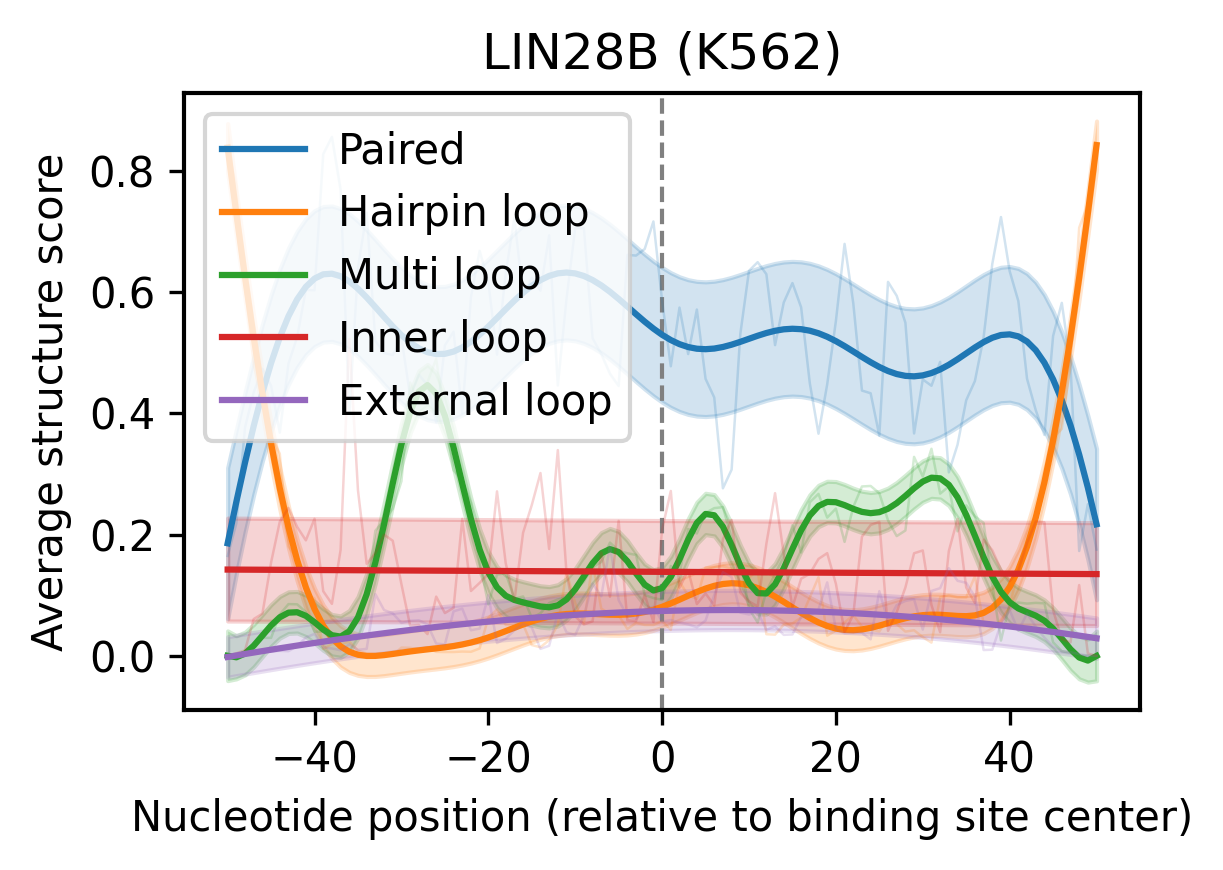

Saved GPR profile: /home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/notebooks/Fig3/LIN28B_K562_combined_profile_profile_gpr.pdf


In [7]:
# GPR only
fig_gpr = make_profile_gpr_figure(
    parsed.structure_scores,
    title=title,
    rbf_length_scale=1.0,  # larger => smoother
    noise_level=0.05,
)

fig_gpr.savefig(gpr_path)
plt.show()
plt.close(fig_gpr)

print("Saved GPR profile:", gpr_path)


In [8]:
from pathlib import Path

# ---- Paths / metadata ----
input_path = Path("/home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/results/cross_cell_type/DDX52_K562_combined_profile.txt")
output_dir = Path("/home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/notebooks/Fig3")

prefix = "DDX52_K562_combined_profile"
title = "DDX52 (K562)"

output_dir.mkdir(parents=True, exist_ok=True)

heatmap_path = output_dir / f"{prefix}_heatmap.pdf"
gpr_path = output_dir / f"{prefix}_profile_gpr.pdf"

# ---- Parse (no plotting) ----
parsed = read_combined_profile_txt(input_path)

# ---- Heatmap matrix (no plotting) ----
mean_matrix, row_labels = mean_profiles(parsed.structure_scores)
mean_matrix_z = zscore_rows(mean_matrix)

print("Parsed blocks:", len(parsed.headers))
print("Heatmap matrix shape:", mean_matrix_z.shape)  # should be (5, 101)
print("Will save to:", heatmap_path, "and", gpr_path)


Parsed blocks: 29
Heatmap matrix shape: (5, 101)
Will save to: /home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/notebooks/Fig3/DDX52_K562_combined_profile_heatmap.pdf and /home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/notebooks/Fig3/DDX52_K562_combined_profile_profile_gpr.pdf


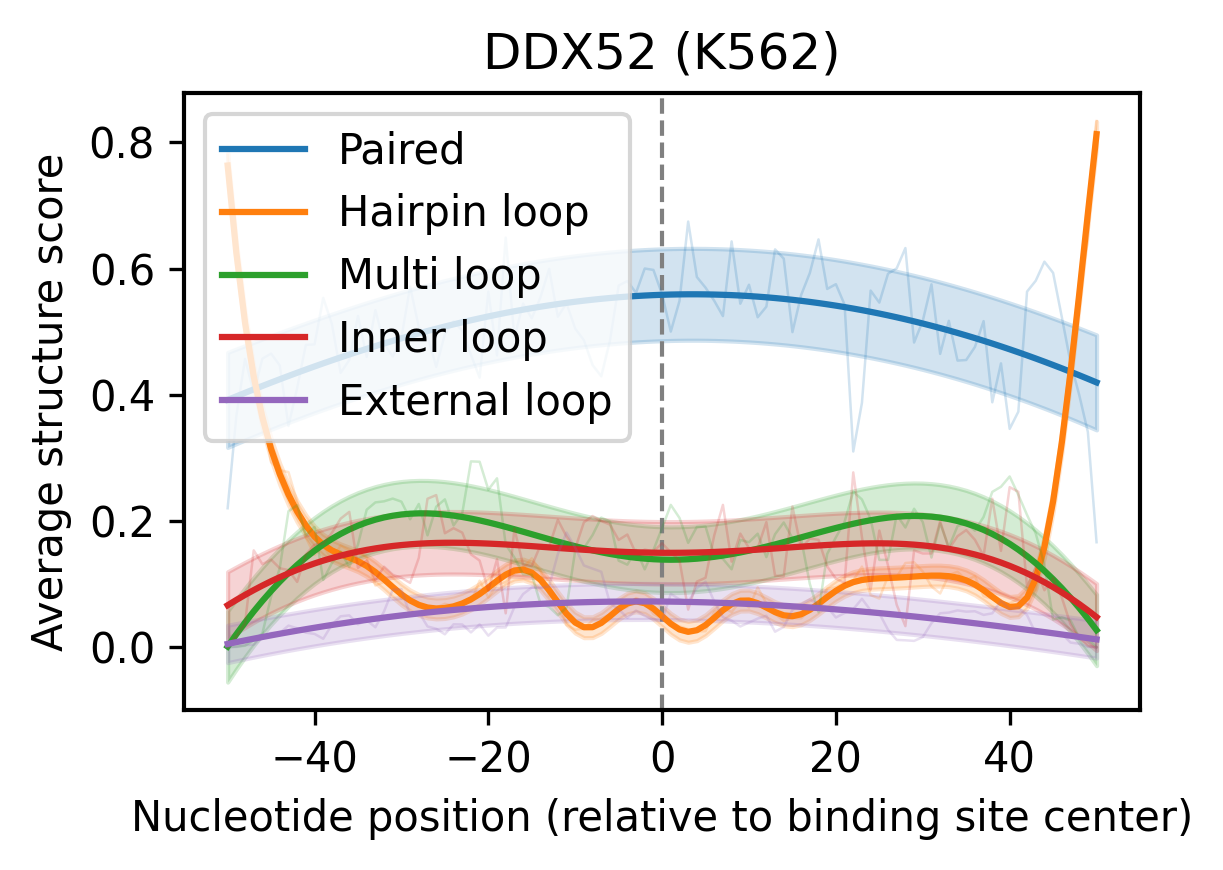

Saved GPR profile: /home/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility/notebooks/Fig3/DDX52_K562_combined_profile_profile_gpr.pdf


In [9]:
# GPR only
fig_gpr = make_profile_gpr_figure(
    parsed.structure_scores,
    title=title,
    rbf_length_scale=1.0,  # larger => smoother
    noise_level=0.05,
)

fig_gpr.savefig(gpr_path)
plt.show()
plt.close(fig_gpr)

print("Saved GPR profile:", gpr_path)
